# 17. Peak–Gene Correlation Database

Build a comprehensive Pearson rho database for every (peak_id, gene) pair that was linked in ANY species' SCENIC+ run.

## Approach

**ATAC:** Use pre-computed pseudobulk cut-site count matrices from `12_fragment_matrices/{species}/pseudobulk_counts.parquet`. These cover the **full final peakset** per species (all peak_ids), and are already grouped by cell_type × donor × region. We aggregate to cell_type × donor to match RNA.

**RNA:** Single combined h5ad with all 6 species (`nhp_atlas_merged_scvi_input_20250520_112026.h5ad`), 12,785 cross-species HGNC gene symbols. Pseudobulk per species by cell_type_initial × Individual using `get_pseudobulk()`.

**Why not ACC_GEX.h5mu?**  
The fragment matrices cover the complete peakset (e.g. 992K peaks for Bonobo), whereas ACC_GEX.h5mu only contains the cisTopic model subset (370K for Bonobo).

**Outputs:**
- `peak_gene_rho_database.parquet` — wide table: peak_id | gene | rho_Human | rho_Gorilla | ...
- `peak_gene_rho_filtered_rho01.parquet` — subset with |rho| > 0.1 in at least one species

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import pyranges as pr
import anndata as ad
import warnings
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

/local1/scratch/jjans/miniforge3/envs/scenicplus_scenicplus10a2_py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SPECIES = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Marmoset", "Macaque"]

SCPLUS_DIR   = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/scenicplus")
FRAGS_DIR    = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/12_fragment_matrices")
PEAKSET_DIR  = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/10_final")
RNA_PATH     = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/rna/integration/scvi_integration/nhp_atlas_merged_scvi_input_20250520_112026.h5ad")
OUT_DIR      = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/17_peak_gene_rho_db")
OUT_DIR.mkdir(exist_ok=True)

# Column names
RNA_CT_COL  = "cell_type_initial"
RNA_IND_COL = "Individual"
RNA_SP_COL  = "Species"

print("Paths configured.")

# ── Colour palettes (consistent across all notebooks) ──────────────────────
CELL_TYPE_COLORS = {
    "Enterocyte":             "#4e9a06",
    "Goblet cell":            "#8f5902",
    "Paneth cell":            "#ce5c00",
    "Tuft cell":              "#c17d11",
    "Enteroendocrine cell":   "#75507b",
    "Stem cell":              "#3465a4",
    "Transit amplifying cell":"#204a87",
    "Stromal cell":           "#a40000",
    "Endothelial cell":       "#cc0000",
    "Smooth muscle cell":     "#ef2929",
    "Macrophage":             "#555753",
    "Dendritic cell":         "#888a85",
    "T cell":                 "#babdb6",
    "B cell":                 "#d3d7cf",
    "Mast cell":              "#eeeeec",
    "Neuron":                 "#2e3436",
}

BROAD_CLASS_COLORS = {
    "Epithelial": "#4e9a06",
    "Stromal":    "#a40000",
    "Immune":     "#555753",
    "Neuronal":   "#2e3436",
}

SPECIES_COLORS = {
    "Human":      "#2ca02c",
    "Gorilla":    "#1f77b4",
    "Chimpanzee": "#ff7f0e",
    "Bonobo":     "#9467bd",
    "Marmoset":   "#8c564b",
    "Macaque":    "#e377c2",
}

REGION_COLORS = {
    "Colon":          "#d62728",
    "Small_Intestine":"#17becf",
    "Duodenum":       "#bcbd22",
    "Jejunum":        "#7f7f7f",
    "Ileum":          "#e377c2",
}

CELL_TYPE_MAP = {
    "Enterocyte":              "Epithelial",
    "Goblet cell":             "Epithelial",
    "Paneth cell":             "Epithelial",
    "Tuft cell":               "Epithelial",
    "Enteroendocrine cell":    "Epithelial",
    "Stem cell":               "Epithelial",
    "Transit amplifying cell": "Epithelial",
    "Stromal cell":            "Stromal",
    "Endothelial cell":        "Stromal",
    "Smooth muscle cell":      "Stromal",
    "Macrophage":              "Immune",
    "Dendritic cell":          "Immune",
    "T cell":                  "Immune",
    "B cell":                  "Immune",
    "Mast cell":               "Immune",
    "Neuron":                  "Neuronal",
}

def _make_ct_lookup(color_dict):
    """Add underscore/p-transformed variants for programmatic names."""
    lookup = dict(color_dict)
    for name, color in color_dict.items():
        lookup.setdefault(name.replace(" ", "_").replace("+", "p"), color)
    return lookup

CT_COLOR_LOOKUP = _make_ct_lookup(CELL_TYPE_COLORS)
# ───────────────────────────────────────────────────────────────────────────


Paths configured.


## 2. Build union (peak_id, gene) pair set

Load all `region_to_gene_adj.tsv` files, map regions to peak_ids via pyranges overlap, take the union across species.

In [10]:
def bed_to_pyranges(bed_path):
    df = pd.read_csv(bed_path, sep="\t", header=None, usecols=[0,1,2,3],
                     names=["Chromosome","Start","End","peak_id"])
    return pr.PyRanges(df)


def map_regions_to_peak_ids(region_series, peakset_pr):
    """
    Map 'chr:start-end' or 'N:start-end' region strings to peak_ids via overlap.
    Auto-normalises chr prefix to match whatever the peakset uses.
    """
    parsed = region_series.str.extract(r"^(.+?):(\d+)-(\d+)$")
    parsed.columns = ["Chromosome", "Start", "End"]
    parsed["Start"] = parsed["Start"].astype(int)
    parsed["End"]   = parsed["End"].astype(int)
    parsed["region"] = region_series.values
    parsed = parsed.dropna(subset=["Chromosome"])

    # Detect chr-prefix mismatch between regions and peakset
    peakset_has_chr  = peakset_pr.df["Chromosome"].iloc[0].startswith("chr")
    regions_have_chr = parsed["Chromosome"].iloc[0].startswith("chr")
    if peakset_has_chr and not regions_have_chr:
        parsed["Chromosome"] = "chr" + parsed["Chromosome"]
    elif not peakset_has_chr and regions_have_chr:
        parsed["Chromosome"] = parsed["Chromosome"].str.replace("^chr", "", regex=True)

    reg_pr = pr.PyRanges(parsed)
    joined = reg_pr.join(peakset_pr, how="left")
    df = joined.df[["region", "peak_id"]].dropna()
    df = df[df["peak_id"].astype(str).str.len() > 0]   # drop empty-string unmatched
    df = df[df["peak_id"] != -1]                        # drop int -1 unmatched
    return df.drop_duplicates("region").set_index("region")["peak_id"].to_dict()

In [11]:
# Load peaksets
peakset_pr = {sp: bed_to_pyranges(PEAKSET_DIR / f"all_peaks_{sp}.bed") for sp in SPECIES}

union_frames = []

for sp in SPECIES:
    path = SCPLUS_DIR / f"scplus_pipeline_{sp}" / "Snakemake" / "region_to_gene_adj.tsv"
    print(f"{sp}: loading...")
    r2g = pd.read_csv(path, sep="\t", usecols=["target", "region"])
    r2g.columns = ["gene", "region"]

    unique_regions = r2g["region"].unique()
    region_map = map_regions_to_peak_ids(pd.Series(unique_regions), peakset_pr[sp])
    r2g["peak_id"] = r2g["region"].map(region_map)
    r2g = r2g.dropna(subset=["peak_id"])[["peak_id", "gene"]]
    print(f"  {len(r2g):,} pairs, {r2g['peak_id'].nunique():,} peaks, {r2g['gene'].nunique():,} genes")
    union_frames.append(r2g)

union_pairs = (
    pd.concat(union_frames, ignore_index=True)
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"\nUnion: {len(union_pairs):,} (peak_id, gene) pairs | "
      f"{union_pairs['peak_id'].nunique():,} peaks | {union_pairs['gene'].nunique():,} genes")

union_pairs.to_csv(OUT_DIR / "union_peak_gene_pairs.tsv", sep="\t", index=False)

Human: loading...
  3,992,408 pairs, 648,999 peaks, 22,399 genes
Gorilla: loading...
  2,731,266 pairs, 541,527 peaks, 16,904 genes
Chimpanzee: loading...
  2,649,151 pairs, 491,999 peaks, 18,760 genes
Bonobo: loading...
  1,333,608 pairs, 283,846 peaks, 16,671 genes
Marmoset: loading...
  3,191,667 pairs, 495,075 peaks, 16,225 genes
Macaque: loading...
  1,978,877 pairs, 364,378 peaks, 17,370 genes

Union: 4,904,105 (peak_id, gene) pairs | 956,171 peaks | 26,636 genes


## 3. ATAC pseudobulk

Load pre-computed fragment count matrices. Aggregate groups by `cell_type × donor` (collapse intestinal segments), then normalise to log1p(CPM).

In [12]:
def load_atac_pseudobulk(species):
    """
    Load pseudobulk_counts.parquet for a species.
    Returns DataFrame indexed by peak_id, columns = 'celltype__donor' keys.
    Values are log1p(CPM) normalised.
    """
    sp_dir = FRAGS_DIR / species
    counts = pd.read_parquet(sp_dir / "pseudobulk_counts.parquet")  # shape: (n_peaks, n_groups+1)
    grp_df = pd.read_parquet(sp_dir / "pseudobulk_groups.parquet")  # cols: cell_type, donor, region, age, label, n_cells

    # Set peak_id as index
    counts = counts.set_index("region_id")

    # Build label -> (cell_type, donor) mapping
    grp_df["ct_donor"] = grp_df["cell_type"].str.replace(" ", "_").str.replace("+", "p") + "__" + grp_df["donor"]
    label_to_ctdonor = grp_df.set_index("label")["ct_donor"].to_dict()

    # Rename columns to ct__donor
    counts.columns = [label_to_ctdonor.get(c, c) for c in counts.columns]

    # Aggregate duplicate ct__donor columns (same cell type, same donor, different region)
    counts = counts.T.groupby(level=0).sum().T

    # Normalise: log1p(CPM)
    col_totals = counts.sum(axis=0)
    counts_norm = np.log1p(counts.div(col_totals, axis=1) * 1e6)

    print(f"  {species}: {counts_norm.shape[0]:,} peaks × {counts_norm.shape[1]} pseudobulk groups")
    return counts_norm


atac_pb = {}
for sp in SPECIES:
    atac_pb[sp] = load_atac_pseudobulk(sp)

  Human: 1,039,336 peaks × 163 pseudobulk groups
  Gorilla: 1,013,198 peaks × 161 pseudobulk groups
  Chimpanzee: 1,029,053 peaks × 103 pseudobulk groups
  Bonobo: 992,889 peaks × 102 pseudobulk groups
  Marmoset: 971,722 peaks × 86 pseudobulk groups
  Macaque: 982,905 peaks × 59 pseudobulk groups


## 4. RNA pseudobulk

Load the combined h5ad, pseudobulk per species by `cell_type_initial × Individual` using `get_pseudobulk()`.

In [13]:
def get_pseudobulk(
    adata,
    group_cols,
    layer='logCPM',
    mode='sum',
    norm_genes=None,
    subset_genes=None,
    threshold=0,
    cell_subsample=None,
    random_state=None,
):
    rng = np.random.default_rng(random_state)
    group_key = '_'.join(group_cols)
    adata.obs[group_key] = adata.obs[group_cols].astype(str).agg('_'.join, axis=1)
    groups = adata.obs[group_key].unique()

    genes_out = list(subset_genes) if subset_genes is not None else list(adata.var_names)
    genes_out = [g for g in genes_out if g in adata.var_names]
    genes_norm = list(norm_genes) if norm_genes is not None else list(adata.var_names)
    genes_norm = [g for g in genes_norm if g in adata.var_names]

    pb_dict, pct_dict, count_dict, lib_sizes = {}, {}, {}, {}

    for group in groups:
        idx = np.where(adata.obs[group_key] == group)[0]
        if cell_subsample is not None:
            n = int(cell_subsample)
            replace = len(idx) < n
            idx = rng.choice(idx, size=n, replace=replace)
        count_dict[group] = len(idx)

        X_norm = adata[idx, genes_norm].X
        lib_sizes[group] = X_norm.sum() if mode == 'sum' else float(np.asarray(X_norm.mean(0)).sum())

        X_sub = adata[idx, genes_out].X
        agg   = X_sub.sum(0) if mode == 'sum' else X_sub.mean(0)
        if sparse.issparse(X_sub):
            n_expr = np.asarray((X_sub > threshold).sum(0)).ravel()
        else:
            n_expr = np.count_nonzero(X_sub > threshold, axis=0)

        pb_dict[group]  = np.ravel(agg.toarray() if sparse.issparse(agg) else agg)
        pct_dict[group] = n_expr / len(idx)

    pb_df  = pd.DataFrame(pb_dict,  index=genes_out).T
    pct_df = pd.DataFrame(pct_dict, index=genes_out).T

    comp_df = pd.DataFrame.from_dict(count_dict, orient='index', columns=['n_cells'])
    meta_lookup = adata.obs[[group_key] + group_cols].drop_duplicates().set_index(group_key)
    comp_df = comp_df.join(meta_lookup).reindex(pb_df.index)

    totals = pd.Series(lib_sizes).reindex(pb_df.index)
    if   layer == 'raw':    pass
    elif layer == 'log':    pb_df = np.log1p(pb_df)
    elif layer == 'CPM':    pb_df = pb_df.div(totals, 0) * 1e6
    elif layer == 'logCPM': pb_df = np.log1p(pb_df.div(totals, 0) * 1e6)
    elif layer == 'CPT':    pb_df = pb_df.div(totals, 0) * 1e4
    elif layer == 'logCPT': pb_df = np.log1p(pb_df.div(totals, 0) * 1e4)
    else: raise ValueError(f"Unknown layer: {layer}")

    return pb_df, pct_df, comp_df

In [14]:
print("Loading RNA h5ad...")
rna_adata = ad.read_h5ad(RNA_PATH)
print(f"RNA: {rna_adata.shape[0]:,} cells × {rna_adata.shape[1]:,} genes")
print(f"Species: {rna_adata.obs[RNA_SP_COL].unique().tolist()}")
print(f"Genes in union_pairs covered: {union_pairs['gene'].isin(rna_adata.var_names).sum():,} / {union_pairs['gene'].nunique():,}")

Loading RNA h5ad...
RNA: 455,024 cells × 12,785 genes
Species: ['Bonobo', 'Macaque', 'Chimpanzee', 'Gorilla', 'Marmoset', 'Human']
Genes in union_pairs covered: 2,981,592 / 26,636


In [15]:
rna_pb = {}  # species -> pb_df (groups x genes)

for sp in SPECIES:
    print(f"\n{sp}: pseudobulking RNA...")
    adata_sp = rna_adata[rna_adata.obs[RNA_SP_COL] == sp].copy()

    # Harmonise cell type names with ATAC (spaces→underscores, +→p)
    adata_sp.obs[RNA_CT_COL] = (
        adata_sp.obs[RNA_CT_COL]
        .str.replace(" ", "_")
        .str.replace("+", "p")
    )

    pb_df, _, comp_df = get_pseudobulk(
        adata_sp,
        group_cols=[RNA_CT_COL, RNA_IND_COL],
        layer='logCPM',
        mode='sum',
    )

    # Rename index from 'celltype_individual' to 'celltype__donor' to match ATAC
    # get_pseudobulk joins with '_' so we rename
    pb_df.index = pb_df.index.str.replace(
        rf"^(.+?)_({RNA_IND_COL})_(.+)$", r"\1__\3", regex=True
    )
    # Simpler: split on last underscore-donor separator
    # group_key was cell_type_initial_Individual → split on RNA_IND_COL
    rna_pb[sp] = pb_df
    print(f"  {pb_df.shape[0]} groups × {pb_df.shape[1]:,} genes")
    print(f"  Sample groups: {list(pb_df.index[:3])}")


Human: pseudobulking RNA...
  184 groups × 12,785 genes
  Sample groups: ['TA_cells_B006', 'Goblet_cells_B006', 'BEST4p_cells_B006']

Gorilla: pseudobulking RNA...
  192 groups × 12,785 genes
  Sample groups: ['Myofibroblasts_GT-1 (SN-523?)', 'Specialized_Fibroblasts_RSPO3p_only_GT-1 (SN-523?)', 'Enterocytes_GT-1 (SN-523?)']

Chimpanzee: pseudobulking RNA...
  117 groups × 12,785 genes
  Sample groups: ['T_cells_BN083', 'ECs_BN083', 'Enterocytes_BN083']

Bonobo: pseudobulking RNA...
  123 groups × 12,785 genes
  Sample groups: ['Plasma_B_cells_BN131', 'Specialized_Fibroblasts_SYNMp_BN131', 'T_cells_BN131']

Marmoset: pseudobulking RNA...
  119 groups × 12,785 genes
  Sample groups: ['Enterocytes_Andrea 16467', 'Myofibroblasts_Andrea 16467', 'TA_cells_Andrea 16467']

Macaque: pseudobulking RNA...
  62 groups × 12,785 genes
  Sample groups: ['TA_cells_Nazisse 2551', 'Specialized_Fibroblasts_SYNMp_Nazisse 2551', 'T_cells_Nazisse 2551']


## 5. Align ATAC and RNA pseudobulk groups

Match groups on `cell_type__donor` key. Check overlap per species.

In [16]:
rna_pb_fixed = {}
for sp in SPECIES:
    print(f"\n{sp}: pseudobulking RNA...")
    adata_sp = rna_adata[rna_adata.obs[RNA_SP_COL] == sp].copy()
    adata_sp.obs["_ct"] = (
        adata_sp.obs[RNA_CT_COL].astype(str)
        .str.replace(" ", "_")
        .str.replace("+", "p")
    )
    # Both columns may be categorical — cast to str before concatenation
    adata_sp.obs["_ct_donor"] = (
        adata_sp.obs["_ct"].astype(str)
        + "__"
        + adata_sp.obs[RNA_IND_COL].astype(str)
    )

    pb_df, _, comp_df = get_pseudobulk(
        adata_sp,
        group_cols=["_ct_donor"],
        layer='logCPM',
        mode='sum',
    )
    rna_pb_fixed[sp] = pb_df
    print(f"  {pb_df.shape[0]} groups × {pb_df.shape[1]:,} genes")
    print(f"  Sample: {list(pb_df.index[:3])}")

rna_pb = rna_pb_fixed


Human: pseudobulking RNA...
  184 groups × 12,785 genes
  Sample: ['TA_cells__B006', 'Goblet_cells__B006', 'BEST4p_cells__B006']

Gorilla: pseudobulking RNA...
  192 groups × 12,785 genes
  Sample: ['Myofibroblasts__GT-1 (SN-523?)', 'Specialized_Fibroblasts_RSPO3p_only__GT-1 (SN-523?)', 'Enterocytes__GT-1 (SN-523?)']

Chimpanzee: pseudobulking RNA...
  117 groups × 12,785 genes
  Sample: ['T_cells__BN083', 'ECs__BN083', 'Enterocytes__BN083']

Bonobo: pseudobulking RNA...
  123 groups × 12,785 genes
  Sample: ['Plasma_B_cells__BN131', 'Specialized_Fibroblasts_SYNMp__BN131', 'T_cells__BN131']

Marmoset: pseudobulking RNA...
  119 groups × 12,785 genes
  Sample: ['Enterocytes__Andrea 16467', 'Myofibroblasts__Andrea 16467', 'TA_cells__Andrea 16467']

Macaque: pseudobulking RNA...
  62 groups × 12,785 genes
  Sample: ['TA_cells__Nazisse 2551', 'Specialized_Fibroblasts_SYNMp__Nazisse 2551', 'T_cells__Nazisse 2551']


In [17]:
# Inspect overlap between ATAC and RNA group keys per species
print(f"{'Species':15s} {'ATAC groups':>12s} {'RNA groups':>12s} {'Shared':>10s}")
for sp in SPECIES:
    atac_keys = set(atac_pb[sp].columns)
    rna_keys  = set(rna_pb[sp].index)
    shared    = atac_keys & rna_keys
    print(f"{sp:15s} {len(atac_keys):>12d} {len(rna_keys):>12d} {len(shared):>10d}")
    if len(shared) == 0:
        print(f"  WARNING: no shared groups! ATAC sample: {list(atac_keys)[:3]}")
        print(f"                              RNA  sample: {list(rna_keys)[:3]}")

Species          ATAC groups   RNA groups     Shared
Human                    163          184        163
Gorilla                  161          192        161
Chimpanzee               103          117        103
Bonobo                   102          123        102
Marmoset                  86          119         86
Macaque                   59           62         59


## 6. Compute Pearson rho

For each (peak_id, gene) pair in the union set, compute Pearson rho across shared pseudobulk groups per species.
Vectorized: iterate over genes, correlate RNA vector with ATAC matrix of all linked peaks simultaneously.

In [18]:
def compute_rho_vectorized(atac_peaks_df, rna_genes_df, pairs_df):
    """
    atac_peaks_df : DataFrame, index=peak_id, columns=group_keys, values=log1p(CPM)
    rna_genes_df  : DataFrame, index=group_keys, columns=gene_symbols, values=logCPM
    pairs_df      : DataFrame with columns [peak_id, gene], integer index

    Returns Series of Pearson rho, indexed like pairs_df. NaN where peak/gene absent.
    """
    shared = atac_peaks_df.columns.intersection(rna_genes_df.index)
    n = len(shared)
    if n < 3:
        return pd.Series(np.nan, index=pairs_df.index)

    atac = atac_peaks_df[shared]   # (n_peaks, n)
    rna  = rna_genes_df.loc[shared]  # (n, n_genes)

    avail_peaks = set(atac.index)
    avail_genes = set(rna.columns)

    result = pd.Series(np.nan, index=pairs_df.index, dtype=float)

    for gene, grp in tqdm(pairs_df.groupby("gene"), desc="genes", leave=False):
        if gene not in avail_genes:
            continue

        rna_vec = rna[gene].values.astype(float)  # (n,)
        rna_std = rna_vec.std()
        if rna_std < 1e-10:
            continue
        rna_z = (rna_vec - rna_vec.mean()) / rna_std

        peaks_here = [p for p in grp["peak_id"] if p in avail_peaks]
        if not peaks_here:
            continue

        # ATAC: (n_peaks_here, n) → transpose to (n, n_peaks)
        atac_mat = atac.loc[peaks_here].values.T.astype(float)  # (n, n_peaks)
        atac_std = atac_mat.std(axis=0)                          # (n_peaks,)

        # Peaks with zero variance: mark as 0 (accessible but flat → no signal)
        has_var  = atac_std > 1e-10
        denom    = np.where(has_var, atac_std, 1.0)
        atac_z   = (atac_mat - atac_mat.mean(axis=0)) / denom   # (n, n_peaks)

        rho_vec  = (rna_z @ atac_z) / (n - 1)  # (n_peaks,)
        rho_vec  = np.where(has_var, rho_vec, np.nan)

        peak_to_rho = dict(zip(peaks_here, rho_vec))

        mask = grp["peak_id"].isin(peak_to_rho)
        result.loc[grp[mask].index] = grp[mask]["peak_id"].map(peak_to_rho).values

    return result

In [ ]:
rho_wide = union_pairs.copy()

for sp in SPECIES:
    print(f"\n=== {sp} ===")

    # ATAC: peak_id as index, groups as columns
    atac_df = atac_pb[sp]  # (n_peaks, n_groups)

    # RNA: groups as index, genes as columns
    rna_df  = rna_pb[sp]   # (n_groups, n_genes)

    shared = set(atac_df.columns) & set(rna_df.index)
    print(f"  Shared pseudobulk groups: {len(shared)}")
    print(f"  ATAC peaks: {len(atac_df):,} | RNA genes: {rna_df.shape[1]:,}")

    rho_sp = compute_rho_vectorized(atac_df, rna_df, union_pairs)

    n_computed = rho_sp.notna().sum()
    print(f"  rho computed: {n_computed:,} / {len(rho_sp):,} pairs ({100*n_computed/len(rho_sp):.1f}%)")
    print(f"  |rho| > 0.1: {(rho_sp.abs() > 0.1).sum():,} | > 0.2: {(rho_sp.abs() > 0.2).sum():,}")

    rho_wide[f"rho_{sp}"] = rho_sp.values

print("\nDone.")


=== Human ===
  Shared pseudobulk groups: 163
  ATAC peaks: 1,039,336 | RNA genes: 12,785


  rho computed: 2,825,781 / 4,904,105 pairs (57.6%)
  |rho| > 0.1: 1,626,286 | > 0.2: 692,628

=== Gorilla ===
  Shared pseudobulk groups: 161
  ATAC peaks: 1,013,198 | RNA genes: 12,785


  rho computed: 2,671,693 / 4,904,105 pairs (54.5%)
  |rho| > 0.1: 1,295,663 | > 0.2: 458,255

=== Chimpanzee ===
  Shared pseudobulk groups: 103
  ATAC peaks: 1,029,053 | RNA genes: 12,785


  rho computed: 2,746,884 / 4,904,105 pairs (56.0%)
  |rho| > 0.1: 1,425,758 | > 0.2: 558,432

=== Bonobo ===
  Shared pseudobulk groups: 102
  ATAC peaks: 992,889 | RNA genes: 12,785


  rho computed: 2,644,781 / 4,904,105 pairs (53.9%)
  |rho| > 0.1: 1,295,170 | > 0.2: 396,474

=== Marmoset ===
  Shared pseudobulk groups: 86
  ATAC peaks: 971,722 | RNA genes: 12,785


genes:  46%|█████████████████████████████████████████                                                 | 12167/26636 [00:09<00:02, 6505.71it/s]

## 7. Save

In [ ]:
rho_cols = [f"rho_{sp}" for sp in SPECIES]

rho_wide["rho_mean"]           = rho_wide[rho_cols].mean(axis=1)
rho_wide["rho_std"]            = rho_wide[rho_cols].std(axis=1)
rho_wide["rho_max"]            = rho_wide[rho_cols].max(axis=1)
rho_wide["n_species_with_rho"] = rho_wide[rho_cols].notna().sum(axis=1)

print(f"Database: {len(rho_wide):,} pairs")
print(f"  rho in all 6 species: {(rho_wide['n_species_with_rho']==6).sum():,}")
print(f"  rho in ≥3 species:    {(rho_wide['n_species_with_rho']>=3).sum():,}")
print(f"  |rho_mean| > 0.1:     {(rho_wide['rho_mean'].abs()>0.1).sum():,}")
print(f"  |rho_max|  > 0.2:     {(rho_wide['rho_max'].abs()>0.2).sum():,}")

rho_wide.to_parquet(OUT_DIR / "peak_gene_rho_database.parquet", index=False)
print(f"\nSaved: {OUT_DIR}/peak_gene_rho_database.parquet")

sig = rho_wide[(rho_wide[rho_cols].abs() > 0.1).any(axis=1)]
sig.to_parquet(OUT_DIR / "peak_gene_rho_filtered_rho01.parquet", index=False)
print(f"Filtered (|rho|>0.1 any species): {len(sig):,} pairs → peak_gene_rho_filtered_rho01.parquet")

## 8. QC

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['figure.dpi'] = 120

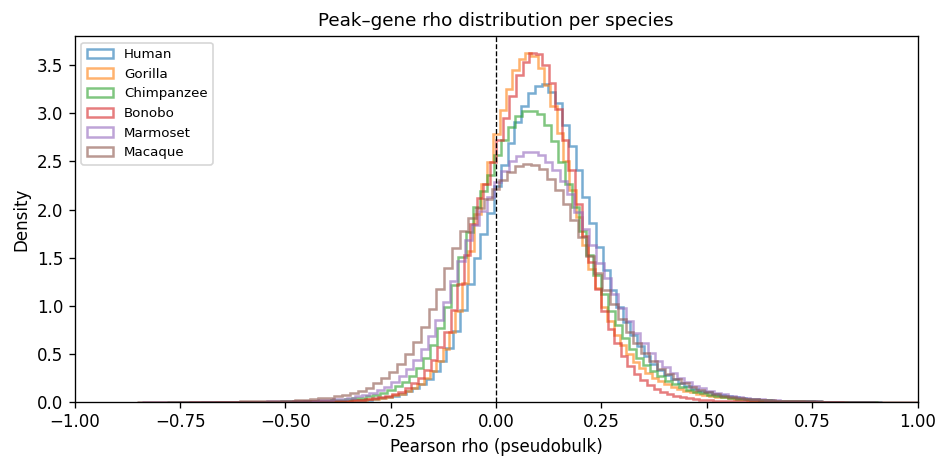

In [27]:
# Distribution of pseudobulk rho per species
fig, ax = plt.subplots(figsize=(8, 4))
for sp in SPECIES:
    vals = rho_wide[f"rho_{sp}"].dropna()
    ax.hist(vals, bins=100, alpha=0.6, density=True, label=sp, histtype='step', lw=1.5)
ax.set_xlabel("Pearson rho (pseudobulk)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Peak–gene rho distribution per species", fontsize=11)
ax.axvline(0, ls='--', color='k', lw=0.8)
ax.legend(fontsize=8)
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_rho_distributions.pdf", bbox_inches='tight')
plt.show()

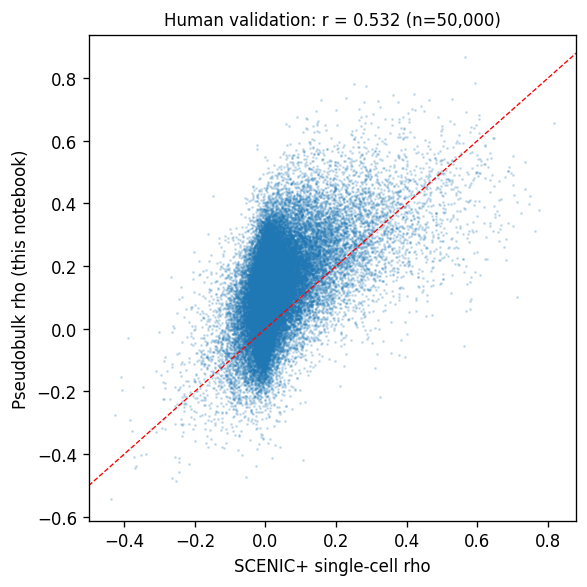

In [25]:
# Validate: compare pseudobulk rho vs SCENIC+ single-cell rho for Human
r2g_human = pd.read_csv(
    SCPLUS_DIR / "scplus_pipeline_Human" / "Snakemake" / "region_to_gene_adj.tsv",
    sep="\t", usecols=["target", "region", "rho"]
)
r2g_human.columns = ["gene", "region", "rho_sc"]
r2g_human["peak_id"] = r2g_human["region"].map(
    map_regions_to_peak_ids(r2g_human["region"], peakset_pr["Human"])
)
r2g_human = r2g_human.dropna(subset=["peak_id"])

compare = rho_wide[["peak_id", "gene", "rho_Human"]].merge(
    r2g_human[["peak_id", "gene", "rho_sc"]], on=["peak_id", "gene"], how="inner"
).dropna()

sample = compare.sample(min(50_000, len(compare)), random_state=42)
r_val  = sample[["rho_sc", "rho_Human"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sample["rho_sc"], sample["rho_Human"], s=0.5, alpha=0.2, rasterized=True)
ax.axline((0, 0), slope=1, color='red', lw=0.8, ls='--')
ax.set_xlabel("SCENIC+ single-cell rho", fontsize=10)
ax.set_ylabel("Pseudobulk rho (this notebook)", fontsize=10)
ax.set_title(f"Human validation: r = {r_val:.3f} (n={len(sample):,})", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_pseudobulk_vs_singlecell_rho_Human.pdf", bbox_inches='tight')
plt.show()

In [26]:
# Coverage summary
print(f"{'Species':15s} {'N computed':>12s} {'% covered':>10s} {'|rho|>0.1':>12s} {'|rho|>0.2':>12s}")
for sp in SPECIES:
    col  = f"rho_{sp}"
    cov  = rho_wide[col].notna().sum()
    sig1 = (rho_wide[col].abs() > 0.1).sum()
    sig2 = (rho_wide[col].abs() > 0.2).sum()
    print(f"{sp:15s} {cov:>12,} {100*cov/len(rho_wide):>9.1f}% {sig1:>12,} {sig2:>12,}")

Species           N computed  % covered    |rho|>0.1    |rho|>0.2
Human              2,825,781      57.6%    1,626,286      692,628
Gorilla            2,671,693      54.5%    1,295,663      458,255
Chimpanzee         2,746,884      56.0%    1,425,758      558,432
Bonobo             2,644,781      53.9%    1,295,170      396,474
Marmoset           2,513,741      51.3%    1,430,669      658,555
Macaque            2,668,489      54.4%    1,510,676      667,994


In [28]:
sig

,peak_id,gene,rho_Human,rho_Gorilla,rho_Chimpanzee,rho_Bonobo,rho_Marmoset,rho_Macaque,rho_mean,rho_std,rho_max,n_species_with_rho
1,unified_494295,A1BG,-0.000405,0.060371,-0.018628,0.202768,-0.030065,NaN,0.042808,0.095979,0.202768,5
2,unified_494294,A1BG,0.177873,-0.024674,-0.044515,0.056722,-0.007007,NaN,0.031680,0.090108,0.177873,5
3,unified_494293,A1BG,0.175328,0.023469,-0.012212,0.116471,-0.090379,0.262097,0.079129,0.129846,0.262097,6
4,unified_494291,A1BG,0.465755,-0.021916,0.024913,0.149177,0.099675,-0.137214,0.096732,0.206351,0.465755,6
5,unified_494290,A1BG,0.372711,NaN,0.159684,0.312347,0.144671,0.177462,0.233375,0.102562,0.372711,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4875454,unified_391245,ZZEF1,0.142231,0.127180,0.052470,0.136999,0.246426,0.174864,0.146695,0.063424,0.246426,6
4875456,macaque_peak_000803,ZZZ3,NaN,NaN,NaN,NaN,NaN,0.146265,0.146265,NaN,0.146265,1
4875457,unified_040761,ZZZ3,NaN,0.060299,0.021829,0.082091,-0.119304,0.128345,0.034652,0.094278,0.128345,5
4875458,unified_040759,ZZZ3,NaN,0.055078,0.124130,0.063855,NaN,-0.188866,0.013549,0.138390,0.124130,4


In [31]:
sig.loc[sig['gene']=='LCT'].sort_values(by='rho_Human',ascending=False)

,peak_id,gene,rho_Human,rho_Gorilla,rho_Chimpanzee,rho_Bonobo,rho_Marmoset,rho_Macaque,rho_mean,rho_std,rho_max,n_species_with_rho
1347654,unified_542632,LCT,0.427403,0.142265,0.164405,0.041450,0.118150,0.164155,0.176305,0.131199,0.427403,6
1347677,unified_542625,LCT,0.424814,0.413477,0.471734,0.189186,0.277579,0.443172,0.369994,0.111206,0.471734,6
1347707,unified_542619,LCT,0.351176,0.414307,0.483036,0.318178,0.283597,0.536850,0.397857,0.098416,0.536850,6
1347716,unified_542585,LCT,0.311719,0.069218,0.068077,0.227374,0.273994,NaN,0.190076,0.114805,0.311719,5
1347709,unified_542584,LCT,0.301542,0.005374,-0.012852,0.261523,0.337291,0.217894,0.185129,0.151739,0.337291,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4771430,unified_542560,LCT,-0.194337,0.043412,0.018197,0.021871,NaN,0.186632,0.015155,0.136147,0.186632,5
4455842,unified_542644,LCT,-0.199021,0.111206,0.004054,0.138241,0.062161,-0.033640,0.013833,0.122434,0.138241,6
1347679,unified_542686,LCT,-0.221315,0.143480,0.265494,0.050199,0.172314,-0.137710,0.045410,0.189134,0.265494,6
4771431,macaque_peak_003625,LCT,NaN,NaN,NaN,NaN,NaN,0.184099,0.184099,NaN,0.184099,1
